## 8.3 시간 의존 슈뢰딩거 방정식(TDSE)과 경제물리학

In [1]:
import numpy as np
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit.quantum_info import Statevector
from qiskit.visualization import plot_bloch_multivector, plot_histogram
from scipy.linalg import expm
import matplotlib.pyplot as plt

%matplotlib inline

import warnings
warnings.filterwarnings('ignore')

In [2]:
# 파라미터
dt = 0.1  # 시간 간격
t_max = 1.0  # 최대 시간
num_steps = int(t_max / dt)

In [3]:
# 단순 해밀토니안 정의 (예: Pauli-Z 연산자)
H = np.array([[1, 0], [0, -1]])  # 단순화한 시장 동역학을 표현

In [4]:
# 초기 양자 상태 (예: 초기 시장 조건)
initial_state = np.array([1, 0])  # |0> 상태

In [5]:
# 시간 진화 연산자 U = exp(-i * H * dt)
U = expm(-1j * H * dt)

In [6]:
# 1큐비트 양자회로 초기화
qc = QuantumCircuit(1)

In [7]:
# 상태 초기화
qc.initialize(initial_state, 0)

In [8]:
# 각 시간 단계마다 시간 진화 적용
for _ in range(num_steps):
    qc.unitary(U, [0], label='U(t)')

In [9]:
# 회로 출력
print(qc)

   ┌─────────────────┐┌──────┐┌──────┐┌──────┐┌──────┐┌──────┐┌──────┐┌──────┐»
q: ┤ Initialize(1,0) ├┤ U(t) ├┤ U(t) ├┤ U(t) ├┤ U(t) ├┤ U(t) ├┤ U(t) ├┤ U(t) ├»
   └─────────────────┘└──────┘└──────┘└──────┘└──────┘└──────┘└──────┘└──────┘»
«   ┌──────┐┌──────┐┌──────┐
«q: ┤ U(t) ├┤ U(t) ├┤ U(t) ├
«   └──────┘└──────┘└──────┘


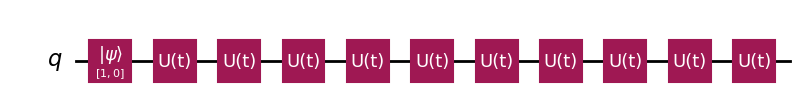

In [10]:
# 회로 시각화
qc.draw('mpl')
plt.show()

In [11]:
# 시간 진화 후 양자 상태 시뮬레이션
simulator = AerSimulator()
qc.save_statevector()
compiled_circuit = transpile(qc, simulator)
result = simulator.run(compiled_circuit).result()

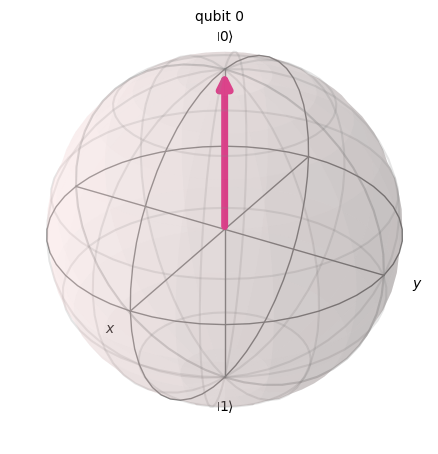

In [12]:
# 상태벡터 획득 후 블로흐 구 그리기
statevector = result.get_statevector()
plot_bloch_multivector(statevector).show()

In [13]:
# 큐비트 측정
qc.measure_all()

In [14]:
# 측정 시뮬레이션
compiled_circuit = transpile(qc, simulator)
result = simulator.run(compiled_circuit).result()
counts = result.get_counts()

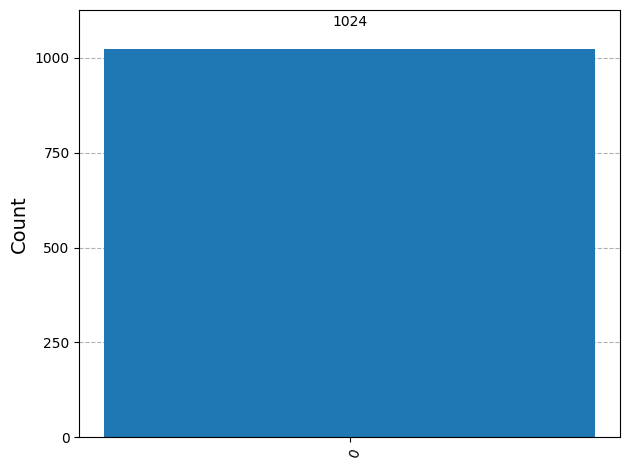

In [15]:
# 결과를 히스토그램으로 그리기
plot_histogram(counts).show()